In [1]:
import os
import sys
sys.path.append("../") # go to parent dir
%load_ext autoreload
%autoreload 2

In [2]:
from functions.loading_functions import *
train_df = get_dataset("train")
train_df

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,class_id,ImagePath
0,ID_nBgcAR.jpg,healthy,1.0,75.0,15.0,162.0,195.0,2,dataset/images/train/ID_nBgcAR.jpg
1,ID_nBgcAR.jpg,healthy,1.0,58.0,1.0,133.0,171.0,2,dataset/images/train/ID_nBgcAR.jpg
2,ID_nBgcAR.jpg,healthy,1.0,42.0,29.0,377.0,349.0,2,dataset/images/train/ID_nBgcAR.jpg
3,ID_Kw2v8A.jpg,healthy,1.0,112.0,124.0,404.0,341.0,2,dataset/images/train/ID_Kw2v8A.jpg
4,ID_Kw2v8A.jpg,healthy,1.0,148.0,259.0,413.0,412.0,2,dataset/images/train/ID_Kw2v8A.jpg
...,...,...,...,...,...,...,...,...,...
9787,ID_WULBQy.jpeg,anthracnose,1.0,136.0,1440.0,1593.0,4000.0,0,dataset/images/train/ID_WULBQy.jpeg
9788,ID_WULBQy.jpeg,anthracnose,1.0,89.0,0.0,1174.0,1139.0,0,dataset/images/train/ID_WULBQy.jpeg
9789,ID_SVzl5X.jpeg,anthracnose,1.0,18.0,360.0,1800.0,2330.0,0,dataset/images/train/ID_SVzl5X.jpeg
9790,ID_xDTIEp.jpeg,anthracnose,1.0,736.0,174.0,2691.0,4032.0,0,dataset/images/train/ID_xDTIEp.jpeg


## Mean Average Precision @ Intersection over Union (IoU) Threshold - 0.5 (Competition's evaluation metric)

**1. Intersection over Union (IoU)**

* **Definition:** IoU is a measure of how much two bounding boxes overlap. It's calculated as the area of intersection divided by the area of union of the predicted bounding box and the ground truth (actual) bounding box.
    * Mathematically:
        ```
        IoU = Area(Intersection) / Area(Union)
        ```
* **Purpose:** IoU helps determine how well a predicted bounding box matches the actual location of an object.
* **Threshold (0.5):** In this specific case, the IoU threshold is set to 0.5. This means that a predicted bounding box is considered a "true positive" only if its IoU with the corresponding ground truth box is greater than or equal to 0.5. If the IoU is below 0.5, the prediction is considered a "false positive."

**2. Precision**

* **Definition:** Precision measures the proportion of predicted positive cases that were actually correct.
    * Mathematically:
        ```
        Precision = True Positives / (True Positives + False Positives)
        ```
* **Purpose:** Precision tells us how accurate the model's positive predictions are.

**3. Average Precision (AP)**

* **Definition:** AP summarizes the precision-recall curve. The precision-recall curve shows the trade-off between precision and recall at different threshold values. AP is calculated by finding the area under this curve.
* **Purpose:** AP provides a single number that reflects the overall performance of the model across different recall levels.
* In object detection, AP is typically calculated for each class of objects.

**4. Mean Average Precision (mAP)**

* **Definition:** mAP is the average of the Average Precision (AP) scores for all object classes.
    * Mathematically:
        ```
        mAP = (AP_class1 + AP_class2 + ... + AP_classN) / N
        ```
        where N is the number of classes.
* **Purpose:** mAP provides a single number that summarizes the overall performance of the object detection model across all classes.

**Putting it all together: Mean Average Precision @ IoU 0.5**

* This metric evaluates the object detection model's performance by calculating the mAP, but only considering predictions with an IoU of 0.5 or higher as true positives.
* Essentially, it measures how well the model can accurately locate and classify objects, with a focus on predictions that have at least a 50% overlap with the ground truth.
* This metric is very common, and is often written as mAP@0.5.

**In summary:**

This metric penalizes predictions that don't have a sufficient overlap with the ground truth and provides an average of the models precision over all the classes, providing a robust measurement of the models performance.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Custom dataset for multi-label classification
class PlantDataset(Dataset):
    def __init__(self, df, class_map, transform=None, is_test=False):
        """
        Custom dataset for multi-label plant classification.
        
        Args:
            df: DataFrame with image paths and class info
            class_map: Dictionary mapping class names to indices
            transform: Image transformations to apply
            is_test: Whether this is a test dataset (no labels)
        """
        self.df = df
        self.class_map = class_map
        self.transform = transform
        self.is_test = is_test
        self.num_classes = len(class_map)
        
        # Group by image ID to handle multiple classes per image
        self.image_ids = self.df['Image_ID'].unique()
        self.image_data = {}
        
        for img_id in self.image_ids:
            img_df = self.df[self.df['Image_ID'] == img_id]
            
            # Get image path (same for all rows with this image ID)
            img_path = img_df['ImagePath'].iloc[0]
            
            # Get all classes for this image
            classes = img_df['class'].unique().tolist() if not is_test else []
            
            # Create one-hot encoded target
            target = np.zeros(self.num_classes)
            for cls in classes:
                if cls in self.class_map:
                    target[self.class_map[cls]] = 1
            
            self.image_data[img_id] = {
                'path': img_path,
                'target': target
            }
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.image_data[img_id]
        img_path = img_info['path']
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a black image in case of error
            image = Image.new('RGB', (224, 224), color='black')
        
        # Apply transformations
        if self.transform:
            image = self.transform(image)
        
        # Return image and target (or just image for test set)
        if self.is_test:
            return image, img_id
        else:
            return image, torch.FloatTensor(img_info['target'])

def prepare_data(df, img_size=224):
    """
    Prepare data for training, validation, and testing.
    
    Args:
        df: DataFrame with image information
        img_size: Size to resize images to
    
    Returns:
        train_loader, val_loader, test_loader, class_map, classes
    """
    # Create class mapping
    classes = sorted(df['class'].unique())
    class_map = {cls: i for i, cls in enumerate(classes)}
    
    # Define transforms
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Split data into train, validation, and test sets
    # First get unique image IDs
    image_ids = df['Image_ID'].unique()
    train_ids, temp_ids = train_test_split(image_ids, test_size=0.3, random_state=42)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)
    
    # Filter dataframe based on image IDs
    train_df = df[df['Image_ID'].isin(train_ids)]
    val_df = df[df['Image_ID'].isin(val_ids)]
    test_df = df[df['Image_ID'].isin(test_ids)]
    
    # Create datasets
    train_dataset = PlantDataset(train_df, class_map, transform=train_transform)
    val_dataset = PlantDataset(val_df, class_map, transform=val_transform)
    test_dataset = PlantDataset(test_df, class_map, transform=val_transform)
    
    # Create data loaders with multiprocessing settings adjusted
    # Using persistent_workers=True and reducing worker count to prevent multiprocessing issues
    train_loader = DataLoader(
        train_dataset, 
        batch_size=32, 
        shuffle=True, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=32, 
        shuffle=False, 
        num_workers=2,
        persistent_workers=True if torch.cuda.is_available() else False,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, test_loader, class_map, classes

def calculate_map(all_targets, all_scores):
    """
    Calculate Mean Average Precision (mAP) for multi-label classification.
    
    Args:
        all_targets: Ground truth binary labels (N x C)
        all_scores: Predicted scores/probabilities (N x C)
    
    Returns:
        mAP score and per-class AP scores
    """
    n_classes = all_targets.shape[1]
    ap_scores = []
    
    for c in range(n_classes):
        # Skip classes with no positive examples in the ground truth
        if np.sum(all_targets[:, c]) == 0:
            ap_scores.append(np.nan)  # Use NaN for classes with no positive examples
            continue
        
        # Calculate AP for this class
        ap = average_precision_score(all_targets[:, c], all_scores[:, c])
        ap_scores.append(ap)
    
    # Calculate mAP by averaging over classes (ignoring NaN values)
    valid_scores = [score for score in ap_scores if not np.isnan(score)]
    mAP = np.mean(valid_scores) if valid_scores else 0.0
    
    return mAP, ap_scores

def train_model(model, train_loader, val_loader, class_names, num_epochs=20, learning_rate=0.001, 
             use_kfold=False, k_folds=5, full_dataset=None, batch_size=32, 
             optimizer_name='adam', early_stopping=False, patience=5, min_delta=0.001):
    
    # Add signal handling for graceful termination
    import signal
    import sys
    
    def signal_handler(sig, frame):
        print('Ctrl+C detected, cleaning up...')
        # Clean up multiprocessing resources
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        sys.exit(0)
    
    # Register signal handler
    signal.signal(signal.SIGINT, signal_handler)
    """
    Train the CNN model with optional k-fold cross-validation.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        class_names: List of class names
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        use_kfold: Whether to use k-fold cross-validation
        k_folds: Number of folds for cross-validation
        full_dataset: Full dataset for k-fold (required if use_kfold is True)
        batch_size: Batch size for k-fold data loaders
        optimizer_name: Name of optimizer to use ('adam', 'sgd', 'adamw', or 'rmsprop')
        early_stopping: Whether to use early stopping
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change in validation mAP to qualify as improvement
    
    Returns:
        Trained model and training history
    """
    from sklearn.model_selection import KFold
    
    # Use CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # If k-fold validation is requested
    if use_kfold:
        if full_dataset is None:
            raise ValueError("Full dataset must be provided for k-fold cross-validation")
        
        print(f"Starting {k_folds}-fold cross-validation")
        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_results = []
        
        # Loop through each fold
        for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(full_dataset)))):
            print(f"\nFOLD {fold+1}/{k_folds}")
            print("-" * 60)
            
            # Create data loaders for this fold with adjusted multiprocessing settings
            train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
            val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
            
            fold_train_loader = torch.utils.data.DataLoader(
                full_dataset, 
                batch_size=batch_size,
                sampler=train_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            fold_val_loader = torch.utils.data.DataLoader(
                full_dataset,
                batch_size=batch_size,
                sampler=val_subsampler,
                num_workers=2,
                persistent_workers=True if torch.cuda.is_available() else False,
                pin_memory=torch.cuda.is_available()
            )
            
            # Create a new model instance for this fold
            fold_model = type(model)(len(class_names)).to(device)
            
            # Train model on this fold
            fold_model, fold_history = _train_single_fold(
                fold_model, 
                fold_train_loader, 
                fold_val_loader, 
                class_names, 
                num_epochs, 
                learning_rate, 
                fold=fold+1,
                optimizer_name=optimizer_name,
                early_stopping=early_stopping,
                patience=patience,
                min_delta=min_delta
            )
            
            # Evaluate model on validation set for this fold
            fold_metrics = evaluate_model(fold_model, fold_val_loader, class_names)
            fold_results.append({
                'fold': fold+1,
                'model': fold_model,
                'history': fold_history,
                'mAP': fold_metrics['mAP'],
                'metrics': fold_metrics
            })
            
            print(f"Fold {fold+1} completed. Validation mAP: {fold_metrics['mAP']:.4f}")
            print("-" * 60)
        
        # Find best fold based on mAP
        best_fold = max(fold_results, key=lambda x: x['mAP'])
        print(f"\nCross-validation completed.")
        print(f"Best fold: {best_fold['fold']} with mAP: {best_fold['mAP']:.4f}")
        
        # Calculate average metrics across all folds
        avg_map = np.mean([fold['mAP'] for fold in fold_results])
        print(f"Average mAP across all folds: {avg_map:.4f}")
        
        return best_fold['model'], best_fold['history']
    
    else:
        # Standard training without k-fold
        return _train_single_fold(
            model.to(device), 
            train_loader, 
            val_loader, 
            class_names, 
            num_epochs, 
            learning_rate,
            optimizer_name=optimizer_name,
            early_stopping=early_stopping,
            patience=patience,
            min_delta=min_delta
        )

def _train_single_fold(model, train_loader, val_loader, class_names, num_epochs, learning_rate, 
                      fold=None, optimizer_name='adam', early_stopping=False, patience=5, min_delta=0.001):
    """
    Helper function to train on a single fold or in standard mode.
    Uses Mean Average Precision (mAP) as the evaluation metric.
    
    Includes additional safeguards for multiprocessing and proper cleanup.
    
    Args:
        model: PyTorch model
        train_loader: Training data loader
        val_loader: Validation data loader
        class_names: List of class names
        num_epochs: Number of training epochs
        learning_rate: Learning rate
        fold: Current fold number (if doing k-fold)
        optimizer_name: Name of optimizer to use ('adam', 'sgd', 'adamw', or 'rmsprop')
        early_stopping: Whether to use early stopping
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change in validation mAP to qualify as improvement
    
    Returns:
        Trained model and training history
    """
    # Set multiprocessing start method if not already set
    import multiprocessing
    try:
        if not multiprocessing.get_start_method():
            multiprocessing.set_start_method('spawn')
    except RuntimeError:
        pass  # Method already set
    device = model.device if hasattr(model, 'device') else next(model.parameters()).device
    
    # Loss function
    criterion = nn.BCEWithLogitsLoss()
    
    # Create optimizer based on name
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    elif optimizer_name.lower() == 'adamw':
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
        print(f"Warning: Optimizer {optimizer_name} not recognized. Using Adam as default.")
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_mAP': []
    }
    
    best_val_map = 0.0
    best_model_path = f'best_plant_model{"_fold_"+str(fold) if fold else ""}.pth'
    
    # Early stopping variables
    early_stop_counter = 0
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}{f' (Fold {fold})' if fold else ''}")
        
        # Training phase
        model.train()
        train_loss = 0.0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        
        # Calculate training loss for the epoch
        train_loss = train_loss / len(train_loader.dataset)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        all_targets = []
        all_scores = []  # Store raw scores for mAP calculation
        
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                
                # Forward pass
                outputs = model(images)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item() * images.size(0)
                
                # Store targets and raw scores
                all_targets.append(targets.cpu().numpy())
                all_scores.append(torch.sigmoid(outputs).cpu().numpy())  # Apply sigmoid for probability scores
        
        # Calculate validation metrics
        val_loss = val_loss / len(val_loader.dataset)
        all_targets = np.vstack(all_targets)
        all_scores = np.vstack(all_scores)
        
        # Calculate Mean Average Precision
        val_map, class_ap = calculate_map(all_targets, all_scores)
        
        # Update learning rate based on mAP (using 'max' mode)
        scheduler.step(val_map)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mAP'].append(val_map)
        
        # Print epoch results
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val mAP: {val_map:.4f}")
        
        # Save best model based on mAP
        if val_map > best_val_map + min_delta:
            best_val_map = val_map
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with mAP: {val_map:.4f}")
            
            # Reset early stopping counter if we found a better model
            early_stop_counter = 0
        else:
            # Increment early stopping counter if we didn't improve enough
            early_stop_counter += 1
            
        # Check if we should stop early
        if early_stopping and early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model
    model.load_state_dict(torch.load(best_model_path))
    
    return model, history

def evaluate_model(model, test_loader, class_names):
    """
    Evaluate the trained model on the test set using Mean Average Precision (mAP).
    
    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names
    
    Returns:
        Evaluation metrics including mAP
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    all_targets = []
    all_scores = []  # Raw scores (before threshold)
    all_preds = []   # Binary predictions (after threshold)
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(images)
            scores = torch.sigmoid(outputs)  # Convert to probabilities
            preds = scores > 0.5  # Binary predictions using 0.5 threshold
            
            # Store targets and predictions
            all_targets.append(targets.cpu().numpy())
            all_scores.append(scores.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    # Concatenate results
    all_targets = np.vstack(all_targets)
    all_scores = np.vstack(all_scores)
    all_preds = np.vstack(all_preds)
    
    # Calculate mAP
    mAP, class_aps = calculate_map(all_targets, all_scores)
    
    # Calculate traditional metrics for reference
    precision, recall, f1, support = precision_recall_fscore_support(
        all_targets, all_preds, average=None, zero_division=0
    )
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='macro', zero_division=0
    )
    
    # Print classification report
    print("\nClassification Report (Multi-label):")
    for i, cls_name in enumerate(class_names):
        print(f"Class: {cls_name}")
        print(f"  Average Precision: {class_aps[i]:.4f}" if not np.isnan(class_aps[i]) else "  Average Precision: N/A (no positive samples)")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  Recall: {recall[i]:.4f}")
        print(f"  F1-Score: {f1[i]:.4f}")
        print(f"  Support: {support[i]}")
    
    print("\nOverall Metrics:")
    print(f"  Mean Average Precision (mAP): {mAP:.4f}")
    print(f"  Macro Precision: {macro_precision:.4f}")
    print(f"  Macro Recall: {macro_recall:.4f}")
    print(f"  Macro F1: {macro_f1:.4f}")
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support,
        'class_ap': class_aps,
        'mAP': mAP,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1
    }

In [4]:

import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history, fold_histories=None, save_path=None):
    """
    Plot training and validation metrics history.
    
    Args:
        history: Dictionary containing training metrics for the best model.
        fold_histories: Optional list of histories from k-fold cross-validation.
        save_path: Optional path to save the plot. If None, the plot is not saved.
    
    Returns:
        The matplotlib.pyplot module.
    """
    if fold_histories:
        # We have k-fold histories to plot
        fig, axes = plt.subplots(2, 2, figsize=(15, 8))  # Create figure and axes

        # Plot losses from all folds
        for i, fold_hist in enumerate(fold_histories):
            axes[0, 0].plot(fold_hist['train_loss'], linestyle='--', alpha=0.5, label=f'Fold {i+1} Train')
            axes[0, 0].plot(fold_hist['val_loss'], alpha=0.5, label=f'Fold {i+1} Val')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss (All Folds)')
        axes[0, 0].legend()
        axes[0, 0].grid(alpha=0.3)
        
        # Plot mAP scores from all folds
        for i, fold_hist in enumerate(fold_histories):
            axes[0, 1].plot(fold_hist['val_mAP'], alpha=0.7, label=f'Fold {i+1}')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('mAP Score')
        axes[0, 1].set_title('Validation mAP Score (All Folds)')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.3)
        
        # Plot average performance across folds
        avg_train_loss = np.mean([fold['train_loss'] for fold in fold_histories], axis=0)
        avg_val_loss = np.mean([fold['val_loss'] for fold in fold_histories], axis=0)
        std_train_loss = np.std([fold['train_loss'] for fold in fold_histories], axis=0)
        std_val_loss = np.std([fold['val_loss'] for fold in fold_histories], axis=0)
        
        epochs = range(1, len(avg_train_loss) + 1)
        axes[1, 0].plot(epochs, avg_train_loss, label='Avg Train Loss')
        axes[1, 0].plot(epochs, avg_val_loss, label='Avg Val Loss')
        axes[1, 0].fill_between(epochs, avg_train_loss - std_train_loss, avg_train_loss + std_train_loss, alpha=0.2)
        axes[1, 0].fill_between(epochs, avg_val_loss - std_val_loss, avg_val_loss + std_val_loss, alpha=0.2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Average Loss Across Folds')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
        
        # Plot average mAP score across folds
        avg_map = np.mean([fold['val_mAP'] for fold in fold_histories], axis=0)
        std_map = np.std([fold['val_mAP'] for fold in fold_histories], axis=0)
        
        axes[1, 1].plot(epochs, avg_map, label='Avg mAP Score')
        axes[1, 1].fill_between(epochs, avg_map - std_map, avg_map + std_map, alpha=0.2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('mAP Score')
        axes[1, 1].set_title('Average mAP Score Across Folds')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        
    else:
        # Standard training history plot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Create figure and axes
        
        # Plot training and validation loss
        axes[0].plot(history['train_loss'], label='Training Loss')
        axes[0].plot(history['val_loss'], label='Validation Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Plot validation mAP score
        axes[1].plot(history['val_mAP'], label='Validation mAP')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('mAP Score')
        axes[1].set_title('Validation mAP Score')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)

    return plt # return the plt module so you can use plt.show() outside.

The provided code snippet performs the following actions:

1.  **Sets Image Size:**
    * `img_size = 224` defines the desired size of the input images to be 224x224 pixels.

2.  **Data Preparation (Standard Training):**
    * `train_loader, val_loader, test_loader, class_map, class_names = prepare_data(train_df, img_size)`:
        * This line calls a function `prepare_data` which likely handles the loading and preprocessing of image data from a pandas DataFrame `train_df`.
        * It uses the `img_size` variable to resize the images.
        * It returns:
            * `train_loader`: A data loader for the training set.
            * `val_loader`: A data loader for the validation set.
            * `test_loader`: A data loader for the test set.
            * `class_map`: A dictionary mapping class labels to numerical indices.
            * `class_names`: A list of the class names.

3.  **Class Mapping (K-Fold):**
    * `classes = sorted(train_df['class'].unique())`: Extracts the unique class labels from the 'class' column of the `train_df` DataFrame and sorts them.
    * `class_map = {cls: i for i, cls in enumerate(classes)}`: Creates a dictionary called `class_map` that maps each class label (`cls`) to a unique integer index (`i`). This is useful for converting categorical labels into numerical targets for machine learning models.

4.  **Image Transformations:**
    * `train_transform = transforms.Compose([...])`: Defines a sequence of image transformations to be applied to the training data.
    * `transforms.Resize((img_size, img_size))`: Resizes the images to the specified `img_size` (224x224).
    * `transforms.RandomHorizontalFlip()`: Randomly flips images horizontally, adding data augmentation.
    * `transforms.RandomVerticalFlip()`: Randomly flips images vertically, adding data augmentation.
    * `transforms.RandomRotation(30)`: Randomly rotates images by up to 30 degrees, adding data augmentation.
    * `transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1)`: Randomly adjusts the brightness, contrast, saturation, and hue of the images, adding data augmentation.
    * `transforms.ToTensor()`: Converts the images to PyTorch tensors.
    * `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`: Normalizes the tensor images using the specified mean and standard deviation, which are commonly used for pre-trained models on ImageNet. This helps to standardize the input data.

In [5]:

# Define a simple CNN model with residual connections
class PlantResNet(nn.Module):
    def __init__(self, num_classes):
        super(PlantResNet, self).__init__()
        
        # Use a pre-trained ResNet as base (updated for newer PyTorch versions)
        self.base_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        # Replace the final fully connected layer
        num_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Identity()
        
        # Add our own classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
    
    def forward(self, x):
        # Forward pass through base model
        features = self.base_model(x)
        
        # Forward pass through our classifier
        return self.classifier(features)


In [6]:
img_size = 224

# For standard training:
train_loader, val_loader, test_loader, class_map, class_names = prepare_data(train_df, img_size)

# For k-fold, create a dataset for the whole training set
classes = sorted(train_df['class'].unique())
class_map = {cls: i for i, cls in enumerate(classes)}

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

The code snippet performs the following actions, specifically tailored for a k-fold cross-validation setup:

1.  **Splitting Data for K-Fold:**
    * `image_ids = train_df['Image_ID'].unique()`: Extracts the unique image IDs from the training DataFrame (`train_df`).
    * `train_val_ids, test_ids = train_test_split(image_ids, test_size=0.2, random_state=42)`: Splits the image IDs into training/validation sets (`train_val_ids`) and a separate test set (`test_ids`). The `test_size=0.2` indicates that 20% of the images are allocated to the test set. `random_state=42` ensures reproducibility.
    * `train_val_df = train_df[train_df['Image_ID'].isin(train_val_ids)]`: Creates a new DataFrame (`train_val_df`) containing the rows from the original `train_df` that correspond to the training/validation image IDs.
    * `test_df = train_df[train_df['Image_ID'].isin(test_ids)]`: Creates a DataFrame (`test_df`) containing the rows from the original `train_df` that correspond to the test image IDs.

2.  **Creating Datasets:**
    * `full_dataset = PlantDataset(train_val_df, class_map, transform=train_transform)`: Creates a custom dataset (`full_dataset`) using the `PlantDataset` class. This dataset is created using the `train_val_df` (the combined training and validation data), the `class_map` (mapping class labels to indices), and the `train_transform` (defined earlier for data augmentation). This dataset will be used for k-fold cross-validation.
    * `test_dataset = PlantDataset(test_df, class_map, transform=transforms.Compose([...]))`: Creates another custom dataset (`test_dataset`) using the `PlantDataset` class. This dataset is created using the `test_df` (the test data), the `class_map`, and a simplified transformation pipeline that includes resizing, converting to tensors, and normalization, but *without* the random augmentations used for training.

3.  **Creating Test DataLoader:**
    * `test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)`: Creates a PyTorch `DataLoader` for the `test_dataset`. This loader will provide batches of test data during evaluation. `batch_size=32` means each batch will contain 32 images. `shuffle=False` ensures that the test data is not shuffled. `num_workers=4` specifies the number of worker processes to use for data loading.

4.  **Model Initialization:**
    * `num_classes = len(class_map)`: Determines the number of unique classes based on the length of the `class_map` dictionary.
    * `model = PlantResNet(num_classes)`: Initializes a `PlantResNet` model with the correct number of output classes. This model is likely a custom ResNet-based architecture designed for plant disease classification.

In [7]:
# For k-fold, we need the full dataset (exclude the test set)
image_ids = train_df['Image_ID'].unique()
train_val_ids, test_ids = train_test_split(image_ids, test_size=0.2, random_state=42)
train_val_df = train_df[train_df['Image_ID'].isin(train_val_ids)]
test_df = train_df[train_df['Image_ID'].isin(test_ids)]

full_dataset = PlantDataset(train_val_df, class_map, transform=train_transform)
test_dataset = PlantDataset(test_df, class_map, transform=transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]))

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

num_classes = len(class_map)
model = PlantResNet(num_classes)


In [10]:
# Option 1: Standard training
model, history = train_model(
    model, 
    train_loader, 
    val_loader, 
    class_names,
    num_epochs=20,
    learning_rate=0.0005,
    optimizer_name='adamw',  # Using AdamW optimizer
    early_stopping=True,     # Enable early stopping
    patience=3,              # Stop after 7 epochs without improvement
    min_delta=0.002          # Require at least 0.002 improvement in mAP
)


Using device: cuda
Epoch 1/20
Train Loss: 0.3527, Val Loss: 0.3067, Val mAP: 0.9213
Saved best model with mAP: 0.9213
Epoch 2/20
Train Loss: 0.2498, Val Loss: 0.2205, Val mAP: 0.9531
Saved best model with mAP: 0.9531
Epoch 3/20
Train Loss: 0.2189, Val Loss: 0.1575, Val mAP: 0.9689
Saved best model with mAP: 0.9689
Epoch 4/20
Train Loss: 0.2085, Val Loss: 0.2052, Val mAP: 0.9593
Epoch 5/20
Train Loss: 0.1804, Val Loss: 0.1724, Val mAP: 0.9640
Epoch 6/20
Train Loss: 0.1861, Val Loss: 0.1980, Val mAP: 0.9569
Early stopping triggered after 6 epochs


In [13]:
history

{'train_loss': [0.3526520903412378,
  0.2497803617201418,
  0.21889832718658817,
  0.20850074248104442,
  0.1803881992665372,
  0.18608516696888655],
 'val_loss': [0.3066924788120716,
  0.22053865985933632,
  0.157533651759311,
  0.20521911993101508,
  0.17244726809503375,
  0.19796386470768795],
 'val_mAP': [0.9212901054470869,
  0.9531465632747275,
  0.9689000889637837,
  0.9593445464348829,
  0.9640276394192241,
  0.956914115933451]}

<module 'matplotlib.pyplot' from '/home/jason-server/Documents/amini_cocoa_contamination/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py'>

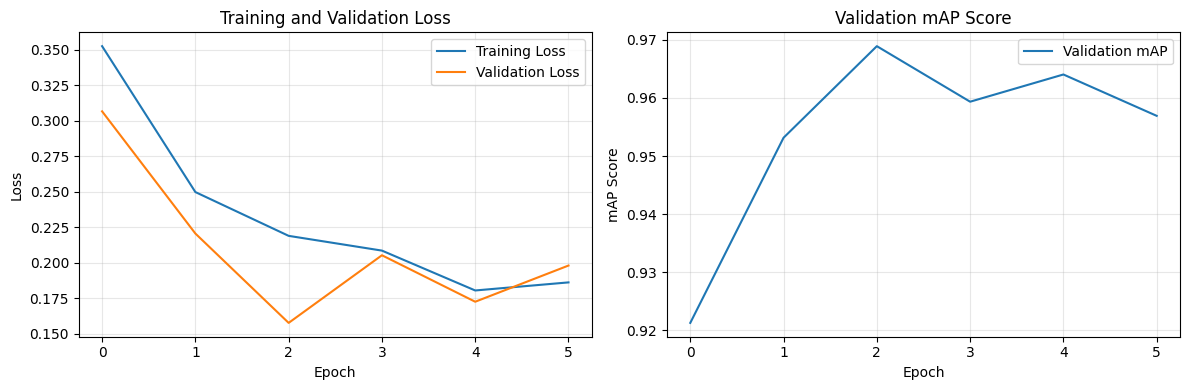

In [21]:
# 5. Plot training history
plot_training_history(history)

In [15]:
# Option 1: Standard training
model, history_1 = train_model(
    model, 
    train_loader, 
    val_loader, 
    class_names,
    num_epochs=20,
    learning_rate=0.0005,
    optimizer_name='adam',  # Using Adam optimizer
    early_stopping=True,     # Enable early stopping
    patience=3,              # Stop after 7 epochs without improvement
    min_delta=0.002          # Require at least 0.002 improvement in mAP
)


Using device: cuda
Epoch 1/20
Train Loss: 0.5390, Val Loss: 0.4977, Val mAP: 0.6762
Saved best model with mAP: 0.6762
Epoch 2/20
Train Loss: 0.5052, Val Loss: 0.4808, Val mAP: 0.7005
Saved best model with mAP: 0.7005
Epoch 3/20
Train Loss: 0.4857, Val Loss: 0.4642, Val mAP: 0.7216
Saved best model with mAP: 0.7216
Epoch 4/20
Train Loss: 0.4787, Val Loss: 0.4740, Val mAP: 0.7396
Saved best model with mAP: 0.7396
Epoch 5/20
Train Loss: 0.4743, Val Loss: 0.4507, Val mAP: 0.7402
Epoch 6/20
Train Loss: 0.4685, Val Loss: 0.4871, Val mAP: 0.7326
Epoch 7/20
Train Loss: 0.4699, Val Loss: 0.4288, Val mAP: 0.7641
Saved best model with mAP: 0.7641
Epoch 8/20
Train Loss: 0.4553, Val Loss: 0.4356, Val mAP: 0.7604
Epoch 9/20
Train Loss: 0.4567, Val Loss: 0.4267, Val mAP: 0.7677
Saved best model with mAP: 0.7677
Epoch 10/20
Train Loss: 0.4538, Val Loss: 0.4480, Val mAP: 0.7793
Saved best model with mAP: 0.7793
Epoch 11/20
Train Loss: 0.4496, Val Loss: 0.4400, Val mAP: 0.7765
Epoch 12/20
Train Loss: 0.

<module 'matplotlib.pyplot' from '/home/jason-server/Documents/amini_cocoa_contamination/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py'>

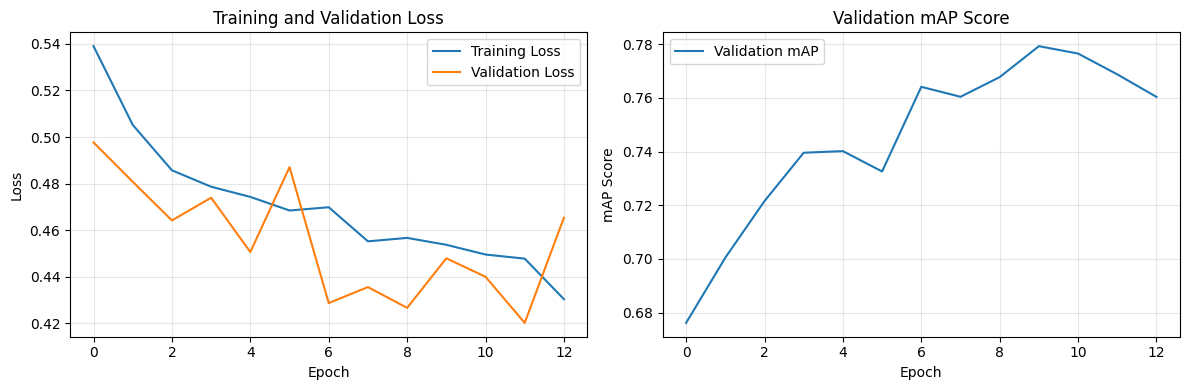

In [20]:
# 5. Plot training history
plot_training_history(history_1)

In [11]:
# Option 2: K-fold cross-validation
model, history = train_model(
    model, 
    None,  # train_loader not needed for k-fold 
    None,  # val_loader not needed for k-fold
    classes,
    num_epochs=10,  # Usually fewer epochs per fold
    learning_rate=0.001,
    use_kfold=True,  # Enable k-fold cross-validation
    k_folds=5,       # Number of folds
    full_dataset=full_dataset,  # Pass your full dataset
    batch_size=64
)

Using device: cuda
Starting 5-fold cross-validation

FOLD 1/5
------------------------------------------------------------
Epoch 1/10 (Fold 1)
Train Loss: 0.3105, Val Loss: 0.1072, Val mAP: 0.8291
Saved best model with mAP: 0.8291
Epoch 2/10 (Fold 1)
Train Loss: 0.2345, Val Loss: 0.0578, Val mAP: 0.9142
Saved best model with mAP: 0.9142
Epoch 3/10 (Fold 1)
Train Loss: 0.2051, Val Loss: 0.0623, Val mAP: 0.8914
Epoch 4/10 (Fold 1)
Train Loss: 0.1863, Val Loss: 0.0650, Val mAP: 0.9248
Saved best model with mAP: 0.9248
Epoch 5/10 (Fold 1)
Train Loss: 0.1569, Val Loss: 0.0609, Val mAP: 0.9125
Epoch 6/10 (Fold 1)
Train Loss: 0.1672, Val Loss: 0.0496, Val mAP: 0.9477
Saved best model with mAP: 0.9477
Epoch 7/10 (Fold 1)
Train Loss: 0.1622, Val Loss: 0.0398, Val mAP: 0.9603
Saved best model with mAP: 0.9603
Epoch 8/10 (Fold 1)
Train Loss: 0.1458, Val Loss: 0.0557, Val mAP: 0.9541
Epoch 9/10 (Fold 1)
Train Loss: 0.1387, Val Loss: 0.0474, Val mAP: 0.9515
Epoch 10/10 (Fold 1)
Train Loss: 0.1350, 

SystemExit: 0

/home/jason-server/Documents/amini_cocoa_contamination/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


<module 'matplotlib.pyplot' from '/home/jason-server/Documents/amini_cocoa_contamination/.venv/lib/python3.10/site-packages/matplotlib/pyplot.py'>

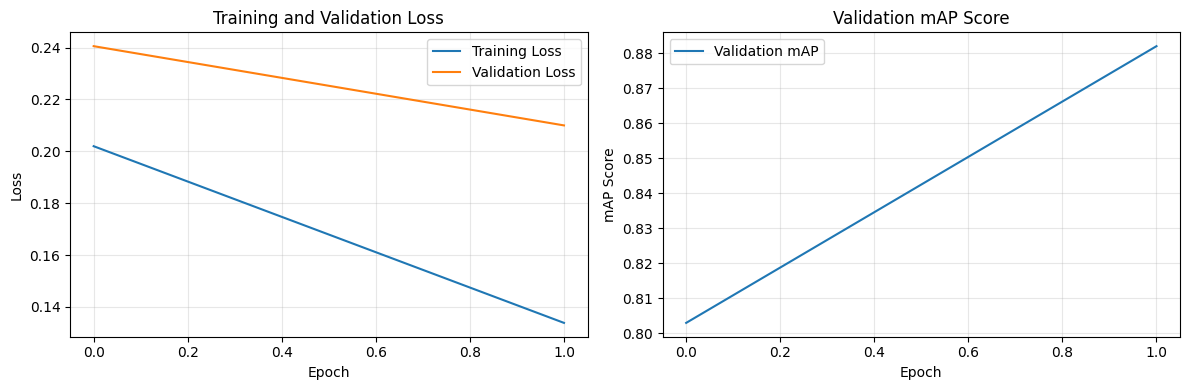

In [9]:
# 5. Plot training history
plot_training_history(history)

In [10]:
metrics = evaluate_model(model, test_loader, classes)


Classification Report (Multi-label):
Class: anthracnose
  Average Precision: 0.8964
  Precision: 0.9637
  Recall: 0.5759
  F1-Score: 0.7209
  Support: 323
Class: cssvd
  Average Precision: 0.8889
  Precision: 0.8536
  Recall: 0.8152
  F1-Score: 0.8339
  Support: 422
Class: healthy
  Average Precision: 0.9048
  Precision: 0.7180
  Recall: 0.9169
  F1-Score: 0.8054
  Support: 361

Overall Metrics:
  Mean Average Precision (mAP): 0.8967
  Macro Precision: 0.8451
  Macro Recall: 0.7693
  Macro F1: 0.7867
